In [1]:
import os
import sys
from torchdiffeq import odeint as odeint

sys.path.append("/Users/jackr/Documents/GitHub/JackRoss-PhD-Notes")

import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib import colors
from mpl_toolkits import mplot3d
from numpy import linalg as la
from scipy import stats
from scipy import spatial as sp
from scipy import integrate as integ
import pandas as pd
import torch
import torch.nn as nn
from tqdm import tqdm
from ipywidgets import interact, IntSlider
import types
import lyapynov as lya 

import multiprocessing as mp

import models.DynamicalSystems as ds

import models.Neural_ODEs_v2 as nodes

In [2]:
device = torch.device("cpu")
torch.set_default_dtype(torch.float32)

In [3]:
lorenz = ds.Lorenz(sigma = 10.0, rho = 28.0, beta = 8.0/3.0)
hopf = ds.Hopf(rho=1.0, alpha = -1.0, omega=0.0, beta=-0.0)
sn = ds.saddlenode(a = -0.5)


In [4]:
lorenz_analysis = ds.DynamicalSystems_analysis(model = lorenz)

In [ ]:
lyapunov_spectrum_out = lorenz_analysis.lyapunov_spectrum(x0 = torch.ones(3, 1, dtype=torch.float32).unsqueeze(0), k = 3, t0 = 0, dt = 0.01, num_pts_compute=10_000, t_transient_pts=1_000)

Computing Lyapunov Spectrum:  29%|██▉       | 2903/10000 [00:13<00:33, 208.95it/s]


KeyboardInterrupt: 

## Lorenz Lyapunov Exponents (Frozen)


In [5]:
lorenz_analysis.model.f = lorenz_analysis.model.na_f

In [6]:
lorenz_analysis.model.drive_rate

0

In [7]:
r_values = np.arange(10.0, 30.0, 0.5)
list = [torch.tensor([1.0, 1.0, 1.0, r], dtype=torch.float32) for r in r_values]
init = torch.stack(list, dim=0)


In [8]:
lyapunov_spectrum_out = lorenz_analysis.lyapunov_spectrum(x0 =init.unsqueeze(2), k = 1, t0 = 0, dt = 0.01, 
                                                              num_pts_compute=10_000, t_transient_pts=1_000, non_autonomous=True)

Computing Lyapunov Spectrum:   0%|          | 0/10000 [00:00<?, ?it/s]

Computing Lyapunov Spectrum: 100%|██████████| 10000/10000 [00:15<00:00, 651.64it/s]


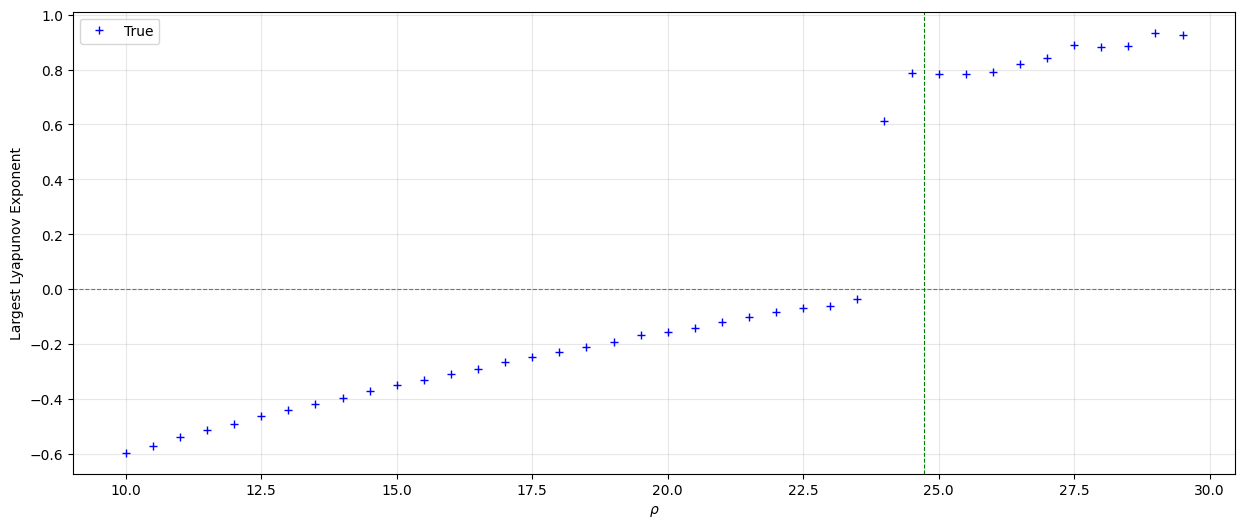

In [9]:
fig, axes = plt.subplots(1, 1, figsize=(15, 6), sharey=True)

# Lorenz plot
axes.plot(r_values, lyapunov_spectrum_out, color='b', linestyle='', marker='+', label='True')


axes.axhline(y=0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
axes.axvline(x=24.72, color='g', linestyle='--', linewidth=0.8, alpha=1)


axes.set_ylabel('Largest Lyapunov Exponent')
axes.set_xlabel(r'$\rho$')
axes.grid(True, alpha=0.3)
axes.legend()


# Trainined Model

In [16]:
os.chdir("/Users/jackr/Documents/GitHub/JackRoss-PhD-Notes/NODE_Dynamic_Bifurcation_Parameter")
os.getcwd()

'/Users/jackr/Documents/GitHub/JackRoss-PhD-Notes/NODE_Dynamic_Bifurcation_Parameter'

In [17]:
model_lorenz = torch.load('networks/lorenz_driven_neural_ODE_m1.pt', weights_only=False).to(device)

In [18]:

node_lorenz = nodes.Neural_DynamicalSystem(model=model_lorenz)
lorenz_analysis_node = ds.DynamicalSystems_analysis(node_lorenz)


In [19]:
print('True System Drive Rate:', lorenz_analysis.model.drive_rate)
print('Neural ODE Drive Rate:', lorenz_analysis_node.model.model.drdt)

True System Drive Rate: 0
Neural ODE Drive Rate: 0.5


## Frozen Lyapunov Exponent of Trained Model

In [ ]:
r_values = np.arange(10.0, 30.0, 0.2)
list = [torch.tensor([1.0, 1.0, 1.0, r]) for r in r_values]
init = torch.stack(list, dim=0)

lorenz_analysis_node.model.model.drdt = 0.00

lle_node_frozen = lorenz_analysis_node.lyapunov_spectrum(x0 =init.unsqueeze(2).float(), k = 1, t0 = 0, dt = 0.05,
                                                              num_pts_compute=5_000, t_transient_pts=0, non_autonomous=False)

In [24]:
lorenz_analysis_node.model.model.drdt = 0.00

In [28]:
lle_node_frozen = lorenz_analysis_node.lyapunov_spectrum(x0 =init.unsqueeze(2).float(), k = 1, t0 = 0, dt = 0.05,
                                                              num_pts_compute=5_000, t_transient_pts=0, non_autonomous=False)

Computing Lyapunov Spectrum: 100%|██████████| 5000/5000 [00:22<00:00, 223.53it/s]


In [27]:
torch.save(lle_node_frozen, 'Lyapunov_EWS_project/llw_node_frozen_lorenz.pt')

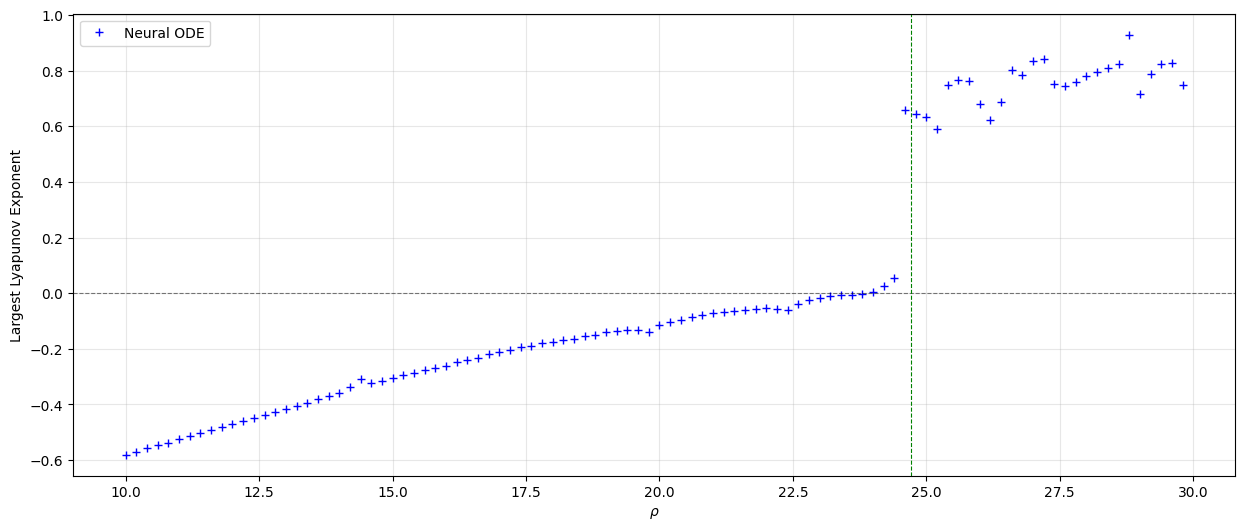

In [26]:
fig, axes = plt.subplots(1, 1, figsize=(15, 6), sharey=True)

# Lorenz plot
axes.plot(r_values, lle_node_frozen.detach().numpy(), color='b', linestyle='', marker='+', label='Neural ODE')


axes.axhline(y=0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
axes.axvline(x=24.72, color='g', linestyle='--', linewidth=0.8, alpha=1)


axes.set_ylabel('Largest Lyapunov Exponent')
axes.set_xlabel(r'$\rho$')
axes.grid(True, alpha=0.3)
axes.legend()

In [ ]:
lorenz_analysis_node.lyapunov_exponents(x0=np.array([1.0, 1.0, 1.0, 28.0]), dt = 0.01, t_span=(50, 200), t0 = 0, num_exponents=1)

array([0.92647368])

## Moving Average Lyapunov Exponents

In [59]:
node_lorenz.model.drdt

0.0

In [60]:
# Get moving average Lyapunov Exponent
node_lorenz.model.drdt = 0.01
lorenz_analysis_node.model.drdt = 0.01

In [68]:
final_r = 20
dt = 0.05
final_t = int(final_r/lorenz_analysis_node.model.drdt)
final_t_pts = int(final_t/dt)

step_pts = int(20/dt)
num_intervals = int(final_t_pts/step_pts)

In [62]:
torch.set_default_device("cpu")

In [63]:
node_lorenz.model.to("cpu")

driven_neural_ODE(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=32, bias=True)
    (7): Tanh()
    (8): Linear(in_features=32, out_features=32, bias=True)
    (9): Tanh()
    (10): Linear(in_features=32, out_features=3, bias=True)
  )
  (activation_func): Tanh()
)

In [ ]:
full_traj = node_lorenz.solve(x0 = torch.tensor([1.0, 1.0, 1.0, 10.0], dtype=torch.float32), t_span=(0, final_t), dt=dt)

In [69]:
init = [full_traj[i*step_pts] for i in range(num_intervals)]

In [70]:
init_tensor = torch.stack(init, dim=0).to(dtype=torch.float32)

In [74]:
lle_node = lorenz_analysis_node.lyapunov_spectrum(x0 =init_tensor.unsqueeze(2), k = 1, t0 = 0, dt = dt,
                                                              num_pts_compute=400, t_transient_pts=0, non_autonomous=False)

Computing Lyapunov Spectrum: 100%|██████████| 400/400 [00:20<00:00, 19.71it/s]


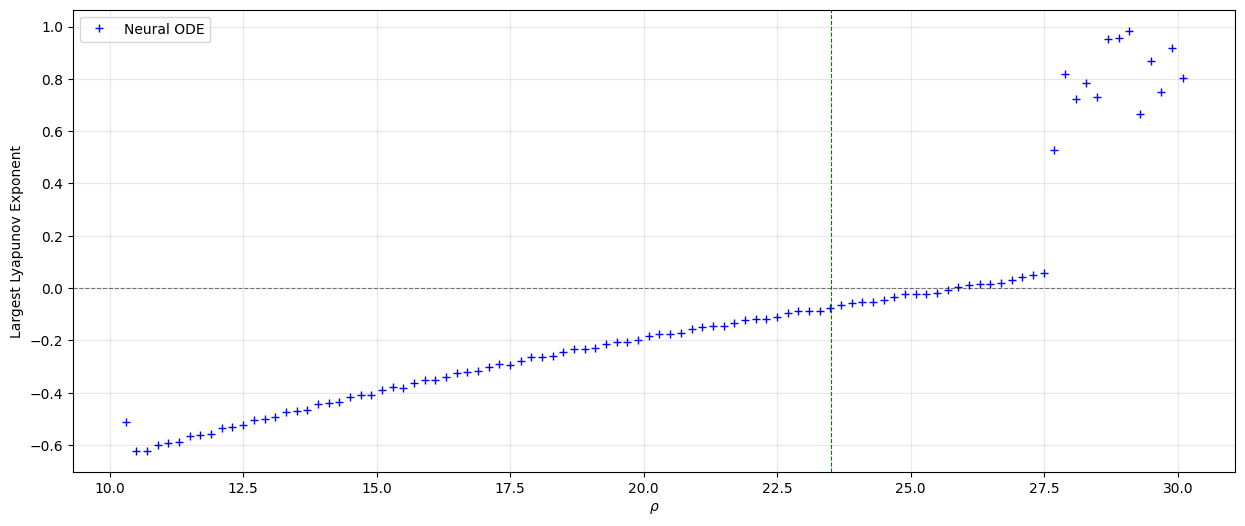

In [78]:
fig, axes = plt.subplots(1, 1, figsize=(15, 6), sharey=True)

# Lorenz plot
axes.plot(init_tensor[:, 3].detach()+0.3, lle_node.detach().numpy(), color='b', linestyle='', marker='+', label='Neural ODE')


axes.axhline(y=0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
axes.axvline(x=23.5, color='g', linestyle='--', linewidth=0.8, alpha=1)


axes.set_ylabel('Largest Lyapunov Exponent')
axes.set_xlabel(r'$\rho$')
axes.grid(True, alpha=0.3)
axes.legend()

In [ ]:
interval_size_list = [20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 300]

In [81]:
lle_node_200 = lorenz_analysis_node.lyapunov_spectrum(x0 =init_tensor.unsqueeze(2), k = 1, t0 = 0, dt = dt,
                                                              num_pts_compute=4_000, t_transient_pts=0, non_autonomous=False)

Computing Lyapunov Spectrum:  19%|█▉        | 768/4000 [00:53<08:16,  6.51it/s] 

: 

In [80]:
list_Intervals = torch.arange(20, 200.0, 20)

In [ ]:
final_t_pts

200000

In [ ]:
for j in tqdm(range(0, len(interval_size_list))):
    ftle_interval_list = []
    interval_size = interval_size_list[j]
    interval_pts = int(interval_size/0.01)

    temp_list = []
    for i in tqdm(range(0, num_intervals)):
        lorenz_lya_node = lya.ContinuousDS(x0 = np.array([1.0, 1.0, 1.0, 10.0]), t0 = 0, f=lambda x, t: node_lorenz.f_numpy(t, x), jac=lambda x, t: node_lorenz.jacobian_numpy(t, x), dt=0.01)
        out = lya.LCE(system = lorenz_lya_node, p=1, n_forward=step_pts*i, n_compute=interval_pts, keep=False)
        temp_list.append(out)


    ftle_interval_list.append(np.array(temp_list))

 82%|████████▏ | 9/11 [24:28:31<5:26:20, 9790.21s/it]


KeyboardInterrupt: 

In [ ]:
ftle_interval_list

[]

In [ ]:
ma_lle_true_lorenz = np.array(temp_list)

In [ ]:
rho_func = lambda t: 11.0 + 0.01*t
rho_pts_lorenz = rho_func(t=np.arange(0, final_t, interval_size))

class linear_regression: 
    def __init__(self, data, target):
            #Adds one for bias
        #(Data points, dimension)
        if not isinstance(data, np.ndarray):
            raise TypeError('Training Data must be np.ndarray but got type:', type(data) )
        elif not isinstance(target, np.ndarray):
            raise TypeError('Target Data must be np.ndarray but got type:', type(target) )
        if not len(data.shape) == len(target.shape) == 2:
            if len(data.shape) == 1: 
                data = np.expand_dims(data, axis=1)
            elif len(target.shape) == 1:
                target = np.expand_dims(data, axis =1)
            else: 
                raise ValueError('Input Data in incorrect shape')
        if data.shape[0] != target.shape[0]:
            raise ValueError("Input data and target data must have same number of observations. However, got Y = ", target.shape[0], " and X = ", data.shape[0])
        
        self.input_dim = data.shape[1]
        self.output_dim = target.shape[1]
        print(data.shape)

        X = np.vstack((data, np.ones(data.shape[0]))).T

        Y = target

        try: 
            inv = np.linalg.inv(X @ X.T)
        except np.linalg.LinAlgError:
            raise ValueError("Could not compute pseuo-inverse of XX^T. Add regularisation")
        
        A = Y @ X.T 

        self.coef = A @ inv 

    def linear_func(self, x):
        if not isinstance(x, np.ndarray):
            try: 
                x = np.array(x)
            except: 
                raise ValueError("Input x cannot be converted into a numpy array. Type x:", type(x))
        
        elif len(x.shape) != 2:
            if len(x.shape) > 2:
                raise ValueError("Input X has too many dimensions. x should have shape no greater than 2 [data_points, dimension]." )
            elif len(x.shape) == 1:
                x = np.expand_dims(x, axis=0)
            elif len(x.shape) == 0:
                x = np.expand_dims(x, axis = 0)
                x = np.expand_dims(x, axis = 0)
        elif not x.shape[1] == self.input_dim:
            raise ValueError('Input X must have input dimension: ', self.input_dim, 'but got ', x.shape[0])
        else: 
          return self.coef @ x
        
    def inv_linear_func(self, y):
        if not isinstance(y, np.ndarray):
            try: 
                y = np.array(y)
            except: 
                raise ValueError("Input y cannot be converted into a numpy array. Type y:", type(y))
        
        elif len(y.shape) != 2:
            if len(y.shape) > 2:
                raise ValueError("Input y has too many dimensions. y should have shape no greater than 2 [data_points, dimension]." )
            elif len(y.shape) == 1:
                x = np.expand_dims(y, axis=0)
            elif len(y.shape) == 0:
                x = np.expand_dims(y, axis = 0)
                x = np.expand_dims(y, axis = 0)
        elif not x.shape[1] == self.output_dim:
            raise ValueError('Input y must have input dimension: ', self.output_dim, 'but got ', y.shape[0])
        else: 
          inv_coef = np.linalg.inv(self.coef)
          return inv_coef @ y
    

        



In [ ]:
class linear_regression_1D: 
    def __init__(self, data, target):

        X = np.vstack((data, np.ones(data.shape[0])))

        Y = target

        inv = np.linalg.inv(X @ X.T)
     
        A = Y.T @ X.T 

        self.coef = A @ inv 

    def linear_func(self, x):
          X = np.vstack((x, np.ones(x.shape[0])))
          return self.coef @ X
        
    def inv_linear_func(self, y):
          inv_coef = np.linalg.inv(self.coef)
          return inv_coef @ y
    

In [ ]:
index = 5
Y = ma_lle_true_lorenz[0:index]
X = rho_pts_lorenz[0:index]
print(Y.shape); print(X.shape)

(5, 1)
(5,)


In [ ]:
linear_func = linear_regression_1D(data = X, target=Y)

In [ ]:
linear_func.coef

array([[ 0.04478284, -1.05219363]])

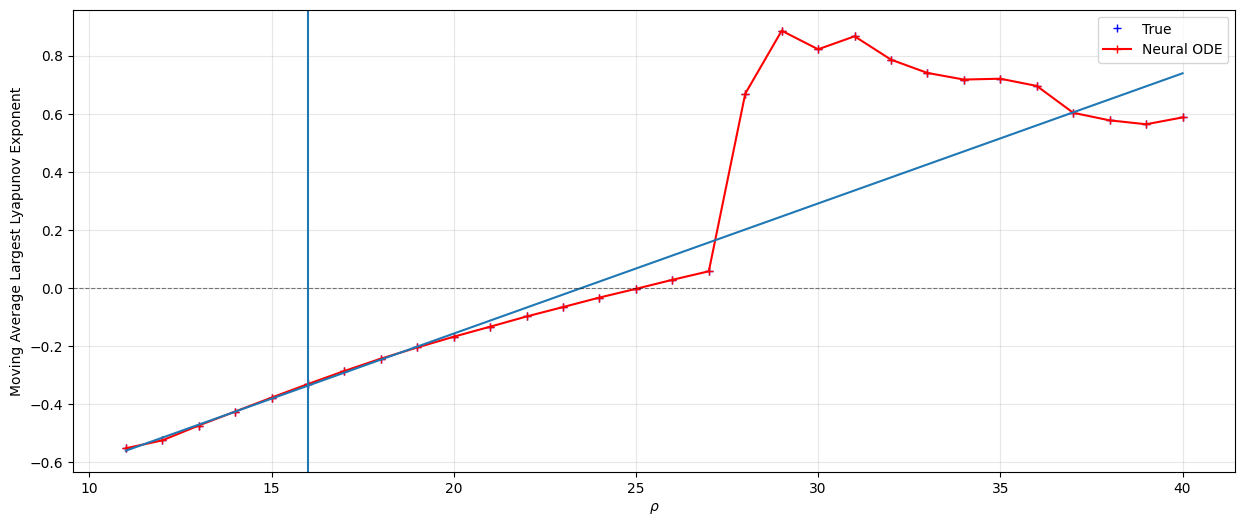

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(15, 6), sharey=True)

# Lorenz plot
axes.plot(rho_pts_lorenz, ma_lle_true_lorenz, color='b', linestyle='', marker='+', label='True')
axes.plot(rho_pts_lorenz, ma_lle_true_lorenz, color='r', linestyle='-', marker='+', label='Neural ODE')
axes.plot(rho_pts_lorenz, linear_func.linear_func(rho_pts_lorenz.T)[0, :])

axes.axhline(y=0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
axes.axvline(x=rho_pts_lorenz[index])

axes.set_ylabel('Moving Average Largest Lyapunov Exponent')
axes.set_xlabel(r'$\rho$')
axes.grid(True, alpha=0.3)
axes.legend()


In [ ]:
# Changing Interval

In [ ]:
list_ma_lorenz_node2 = []
for i in tqdm(range(0, 40)):
    lorenz_lya_node = lya.ContinuousDS(x0 = np.array([1.0, 1.0, 1.0, 10.0]), t0 = 0, f=lambda x, t: node_lorenz.f_numpy(t, x), jac=lambda x, t: node_lorenz.jacobian_numpy(t, x), dt=0.01)
    out = lya.LCE(system = lorenz_lya_node, p=1, n_forward=5_000*i, n_compute=5_000, keep=False)
    list_ma_lorenz_node2.append(out)

100%|██████████| 40/40 [08:45<00:00, 13.14s/it]


In [ ]:
steps = 2_000
num_interval = int(200_000 / steps)

list_ma_lorenz_node3 = []
for i in tqdm(range(0, num_interval)):
    lorenz_lya_node = lya.ContinuousDS(x0 = np.array([1.0, 1.0, 1.0, 10.0]), t0 = 0, f=lambda x, t: node_lorenz.f_numpy(t, x), jac=lambda x, t: node_lorenz.jacobian_numpy(t, x), dt=0.01)
    out = lya.LCE(system = lorenz_lya_node, p=1, n_forward=steps*i, n_compute=steps, keep=False)
    list_ma_lorenz_node3.append(out)

100%|██████████| 100/100 [20:40<00:00, 12.40s/it]


In [ ]:
interval_size = 20_000
steps = 10_000
num_interval = int(200_000 / steps)

list_ma_lorenz_node4 = []
for i in tqdm(range(0, num_interval)):
    lorenz_lya_node = lya.ContinuousDS(x0 = np.array([1.0, 1.0, 1.0, 10.0]), t0 = 0, f=lambda x, t: node_lorenz.f_numpy(t, x), jac=lambda x, t: node_lorenz.jacobian_numpy(t, x), dt=0.01)
    out = lya.LCE(system = lorenz_lya_node, p=1, n_forward=steps*i, n_compute=interval_size, keep=False)
    list_ma_lorenz_node4.append(out)

100%|██████████| 20/20 [05:45<00:00, 17.26s/it]


In [ ]:
rho_func = lambda t: 11.0 + 0.01*t
rho_pts_lorenz1 = rho_func(t=np.arange(0, 2_000, 50))

In [ ]:
rho_func = lambda t: 11.0 + 0.01*t
rho_pts_lorenz2 = rho_func(t=np.arange(0, 2_000, 20))
rho_pts_lorenz3 = rho_func(t=np.arange(0, 2_000, 100))

In [ ]:
rho_pts_lorenz1.shape

(40,)

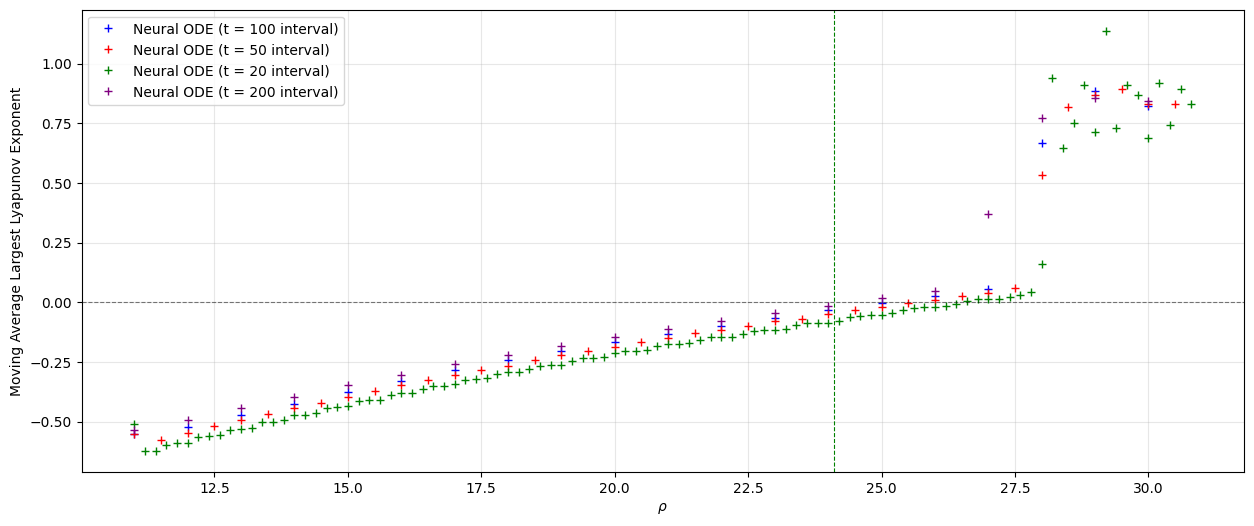

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(15, 6), sharey=True)

# Lorenz plot
axes.plot(rho_pts_lorenz, list_ma_lorenz_node, color='b', linestyle='', marker='+', label='Neural ODE (t = 100 interval)')
axes.plot(rho_pts_lorenz1, list_ma_lorenz_node2, color='r', linestyle='', marker='+', label='Neural ODE (t = 50 interval)')
axes.plot(rho_pts_lorenz2, list_ma_lorenz_node3, color='g', linestyle='', marker='+', label='Neural ODE (t = 20 interval)')
axes.plot(rho_pts_lorenz3, list_ma_lorenz_node4, color='purple', linestyle='', marker='+', label='Neural ODE (t = 200 interval)')
#axes.plot(rho_pts_lorenz, list_ma_lorenz_node, color='r', linestyle='', marker='+', label='Neural ODE')
axes.axhline(y=0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
axes.axvline(x=24.1, color='g', linestyle='--', linewidth=0.8, alpha=1)
axes.set_ylabel('Moving Average Largest Lyapunov Exponent')
axes.set_xlabel(r'$\rho$')
axes.grid(True, alpha=0.3)
axes.legend()


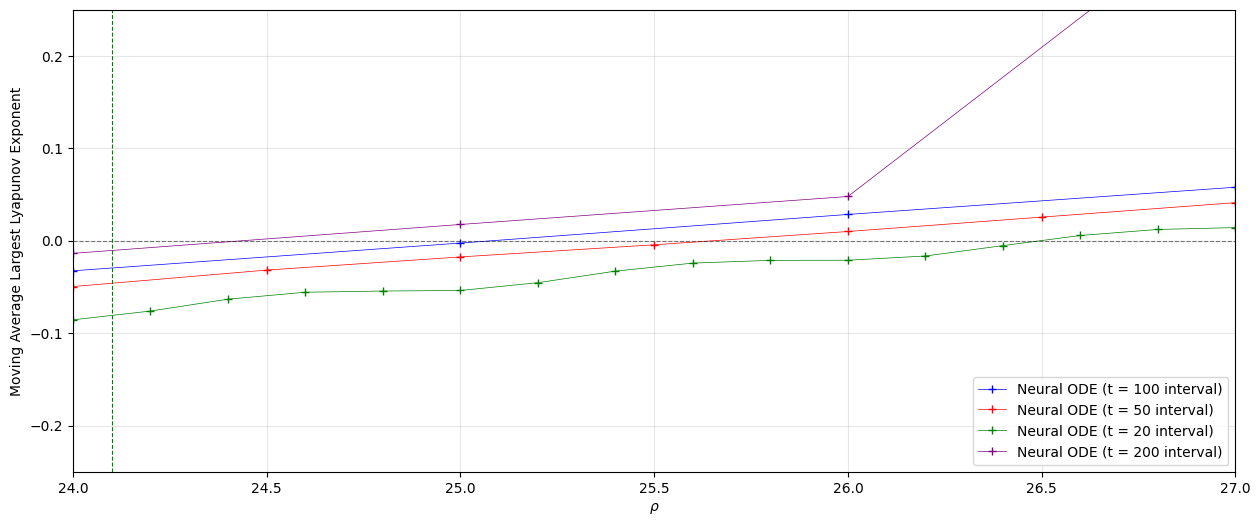

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(15, 6), sharey=True)

# Lorenz plot
axes.plot(rho_pts_lorenz, list_ma_lorenz_node, color='b', linestyle='-', marker='+', linewidth=0.5, label='Neural ODE (t = 100 interval)')
axes.plot(rho_pts_lorenz1, list_ma_lorenz_node2, color='r', linestyle='-', marker='+', linewidth=0.5, label='Neural ODE (t = 50 interval)')
axes.plot(rho_pts_lorenz2, list_ma_lorenz_node3, color='g', linestyle='-', marker='+', linewidth=0.5, label='Neural ODE (t = 20 interval)')
axes.plot(rho_pts_lorenz3, list_ma_lorenz_node4, color='purple', linestyle='-', marker='+', linewidth=0.5, label='Neural ODE (t = 200 interval)')
#axes.plot(rho_pts_lorenz, list_ma_lorenz_node, color='r', linestyle='', marker='+', label='Neural ODE')
axes.axhline(y=0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
axes.axvline(x=24.1, color='g', linestyle='--', linewidth=0.8, alpha=1)
axes.set_xlim(24, 27)
axes.set_ylim(-0.25, 0.25)
axes.set_ylabel('Moving Average Largest Lyapunov Exponent')
axes.set_xlabel(r'$\rho$')
axes.grid(True, alpha=0.3)
axes.legend()

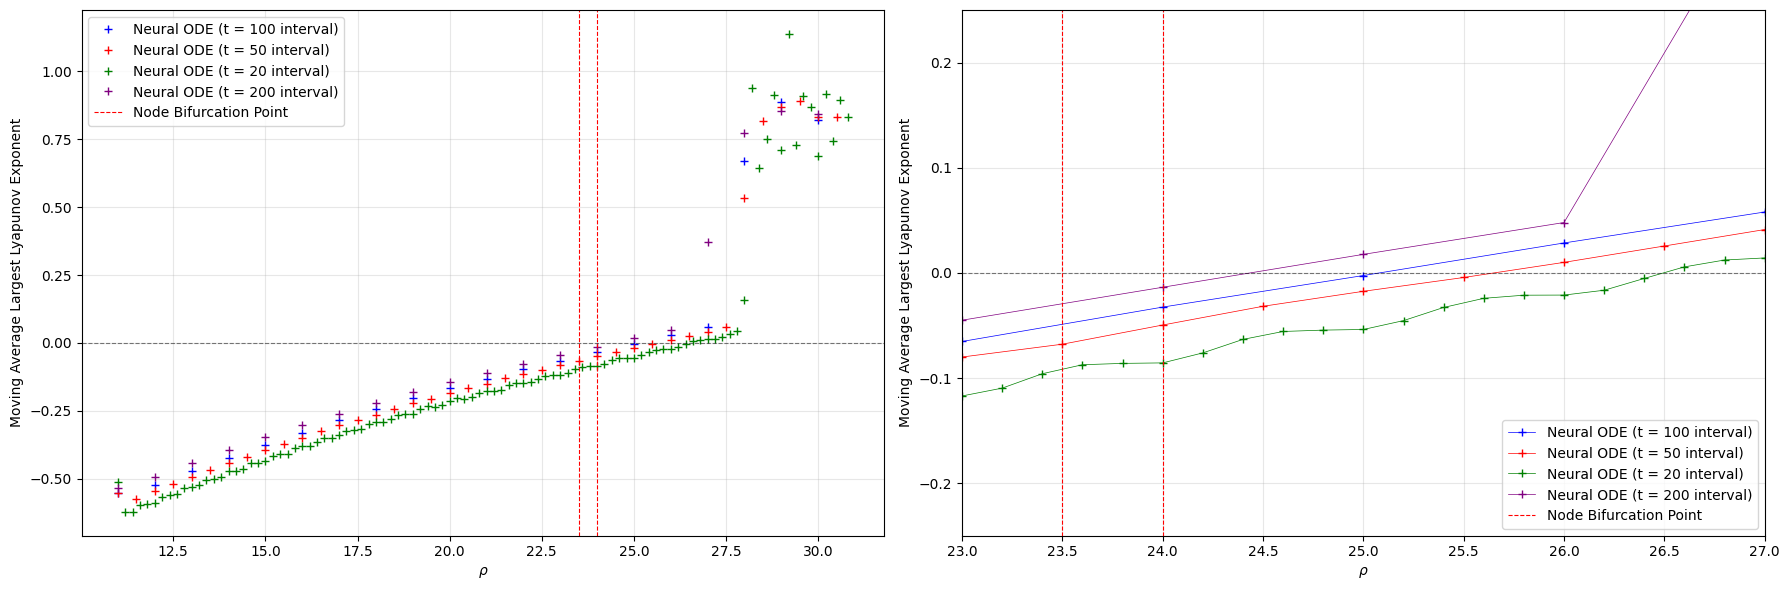

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

# Left plot - Full view (from cell 85)
axes[0].plot(rho_pts_lorenz, list_ma_lorenz_node, color='b', linestyle='', marker='+', label='Neural ODE (t = 100 interval)')
axes[0].plot(rho_pts_lorenz1, list_ma_lorenz_node2, color='r', linestyle='', marker='+', label='Neural ODE (t = 50 interval)')
axes[0].plot(rho_pts_lorenz2, list_ma_lorenz_node3, color='g', linestyle='', marker='+', label='Neural ODE (t = 20 interval)')
axes[0].plot(rho_pts_lorenz3, list_ma_lorenz_node4, color='purple', linestyle='', marker='+', label='Neural ODE (t = 200 interval)')
axes[0].axhline(y=0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].axvline(x=23.5, color='r', linestyle='--', linewidth=0.8, alpha=1)
axes[0].axvline(x=24, color='r', linestyle='--', linewidth=0.8, alpha=1, label='Node Bifurcation Point')
axes[0].set_ylabel('Moving Average Largest Lyapunov Exponent')
axes[0].set_xlabel(r'$\rho$')
#axes[0].set_title('Full View')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Right plot - Zoomed view (from cell 90)
axes[1].plot(rho_pts_lorenz, list_ma_lorenz_node, color='b', linestyle='-', marker='+', linewidth=0.5, label='Neural ODE (t = 100 interval)')
axes[1].plot(rho_pts_lorenz1, list_ma_lorenz_node2, color='r', linestyle='-', marker='+', linewidth=0.5, label='Neural ODE (t = 50 interval)')
axes[1].plot(rho_pts_lorenz2, list_ma_lorenz_node3, color='g', linestyle='-', marker='+', linewidth=0.5, label='Neural ODE (t = 20 interval)')
axes[1].plot(rho_pts_lorenz3, list_ma_lorenz_node4, color='purple', linestyle='-', marker='+', linewidth=0.5, label='Neural ODE (t = 200 interval)')
axes[1].axhline(y=0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1].axvline(x=23.5, color='r', linestyle='--', linewidth=0.8, alpha=1)
axes[1].axvline(x=24, color='r', linestyle='--', linewidth=0.8, alpha=1, label='Node Bifurcation Point')
axes[1].set_xlim(23, 27)
axes[1].set_ylim(-0.25, 0.25)
axes[1].set_ylabel('Moving Average Largest Lyapunov Exponent')
axes[1].set_xlabel(r'$\rho$')
#axes[1].set_title('Zoomed View (\u03c1 = 24-27)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()

In [ ]:
def largest_lyapunov_exponent(model, x0, dt, t_span):
    n_compute = int((t_span[1] - t_span[0]) / dt)
    n_transient = int(t_span[0] / dt)
    lya_system = lya.ContinuousDS(x0 = x0, t0 = 0, f=lambda x, t: model.f_numpy(t, x), jac=lambda x, t: model.jacobian_numpy(t, x), dt=dt)
    out = lya.LCE(system = lya_system, p=1, n_forward=n_compute, n_compute=n_compute, keep=False)
    return out

In [ ]:
# Dynamical Systems Analysis

In [ ]:
class DynamicalSystems_analysis: 
    '''
    Class to analyze the dynamical system, including computing Lyapunov exponents, bifurcation diagrams, and other relevant metrics.

    Attributes:
    - model: The dynamical system model to be analyzed. Should be an instance of DynamicalSystem_torch. 

    Methods:
    - compute_lyapunov_exponent(x0, dt, t_span): Computes the largest Lyapunov exponent for the given initial condition, time step, and time span.

    '''
    def __init__(self, model: ds.DynamicalSystem_torch):
        self.model = model 

    def lyapunov_exponents(self, x0, dt, t_span: tuple, num_exponents=1, keep_data=False):
        '''
        Computes the largest Lyapunov exponent for the given model, initial condition, time step, and time span.

        Uses methods from the lyapynov package to compute the Lyapunov exponent.

        Currently requires numpy array - will need to modify to work with torch tensors in future. 

        Parameters:
        - x0: The initial condition for the system. Should be a numpy array.
        - dt: The time step for the computation.
        - t_span: A tuple (t_start, t_end) specifying the time span for the computation. Computation will start at t = 0 and discard items before t_start as transient, and compute the Lyapunov exponent over the interval [t_start, t_end].

        - num_exponents: The number of Lyapunov exponents to compute. Default is 1 (largest Lyapunov exponent).
        - keep_data: Whether to keep the full data of the Lyapunov exponent computation. Default is False (only keep the final exponent values).
        '''
        if not isinstance(x0, np.ndarray):
            raise ValueError("x0 should be a numpy array.")
        
        if not isinstance(dt, (int, float)):
            raise ValueError("dt should be a numeric value.")
        
        if num_exponents < 1 or num_exponents > self.model.system_dim:
            raise ValueError("num_exponents should be at least 1 and no greater than system dimension ({}).".format(self.model.system_dim))

        n_compute = int((t_span[1] - t_span[0]) / dt)
        n_transient = int(t_span[0] / dt)
        lya_system = lya.ContinuousDS(x0 = x0, t0 = 0, f=lambda x, t: self.model.f_numpy(t, x), jac=lambda x, t: self.model.jacobian_numpy(t, x), dt=dt)
        out = lya.LCE(system = lya_system, p=num_exponents, n_forward=n_transient, n_compute=n_compute, keep=keep_data)
        return out


In [ ]:
class Neural_DynamicalSystem(ds.DynamicalSystem_torch):
    def __init__(self, model):
        super().__init__(dim=model.input_dim)
        self.model = model 

    def f(self, t, x):
        t, x = self.f_tests(t, x)
        return self.model(t, x)
    


In [ ]:
list = []
for i in tqdm(range(0, 4)):
    list.append((10+10*i, 20+10*i))

100%|██████████| 4/4 [00:00<00:00, 111848.11it/s]


In [ ]:
# Use multiprocess instead of multiprocessing for notebook compatibility
# Install with: pip install multiprocess
import multiprocessing as mp

In [ ]:
def test_func(x):
    return x

In [ ]:
def test_func2(x):
    return lorenz_analysis.lyapunov_exponents(x0=np.array([1.0, 1.0, 1.0, 10.0]), dt=0.01, t_span=x, num_exponents=1, keep_data=False)

In [ ]:
with mp.Pool(processes=4) as pool:
    results = pool.map(test_func2, list)

Process SpawnPoolWorker-17:
Process SpawnPoolWorker-20:
Process SpawnPoolWorker-18:
Process SpawnPoolWorker-19:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/L

KeyboardInterrupt: 

In [ ]:
lorenz_analysis = DynamicalSystems_analysis(model=node_lorenz)

lorenz_analysis.lyapunov_exponents(x0=np.array([1.0, 1.0, 1.0, 10.0]), dt=0.01, t_span=(100, 200), num_exponents=1, keep_data=False)

array([-0.52406097])

In [ ]:
def largest_lyapunov_exponent(model, x0, dt, t_span):
    n_compute = int((t_span[1] - t_span[0]) / dt)
    n_transient = int(t_span[0] / dt)
    lya_system = lya.ContinuousDS(x0 = x0, t0 = 0, f=lambda x, t: model.f_numpy(t, x), jac=lambda x, t: model.jacobian_numpy(t, x), dt=dt)
    out = lya.LCE(system = lya_system, p=1, n_forward=n_compute, n_compute=n_compute, keep=False)
    return out